Classification of Pets Face

In [7]:
#Importing the libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

2: Dataset Path

In [8]:
BASE_PATH = r"C:\Users\sahas\Downloads\archive (2)"
IMAGE_DIR = os.path.join(BASE_PATH, "images", "images")

print("Total files:", len(os.listdir(IMAGE_DIR)))

Total files: 7393


3.create dataframe

In [9]:
filepaths = []
labels = []

for file in os.listdir(IMAGE_DIR):
    
    if not file.endswith(".jpg"):
        continue
        
    filepath = os.path.join(IMAGE_DIR, file)
    
    label = file.split("_")[0]   # correct for pet dataset
    
    filepaths.append(filepath)
    labels.append(label)

df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

print(df.head())

                                            filepath       label
0  C:\Users\sahas\Downloads\archive (2)\images\im...  Abyssinian
1  C:\Users\sahas\Downloads\archive (2)\images\im...  Abyssinian
2  C:\Users\sahas\Downloads\archive (2)\images\im...  Abyssinian
3  C:\Users\sahas\Downloads\archive (2)\images\im...  Abyssinian
4  C:\Users\sahas\Downloads\archive (2)\images\im...  Abyssinian


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

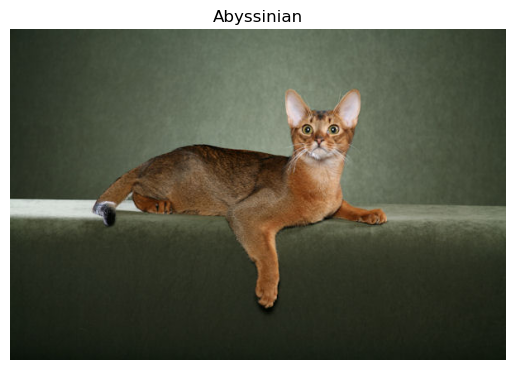

In [10]:
# Allignment

img_path = df.iloc[0]['filepath']
label = df.iloc[0]['label']

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(label)
plt.axis("off")

4. EDA

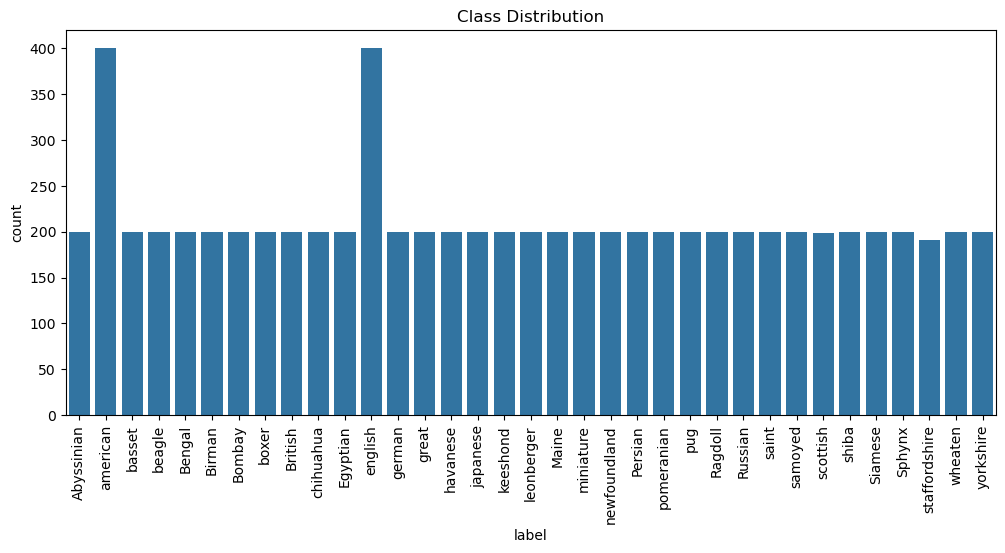

In [11]:
plt.figure(figsize=(12,5))
sns.countplot(x=df['label'])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

5.Evaluating on multiple 

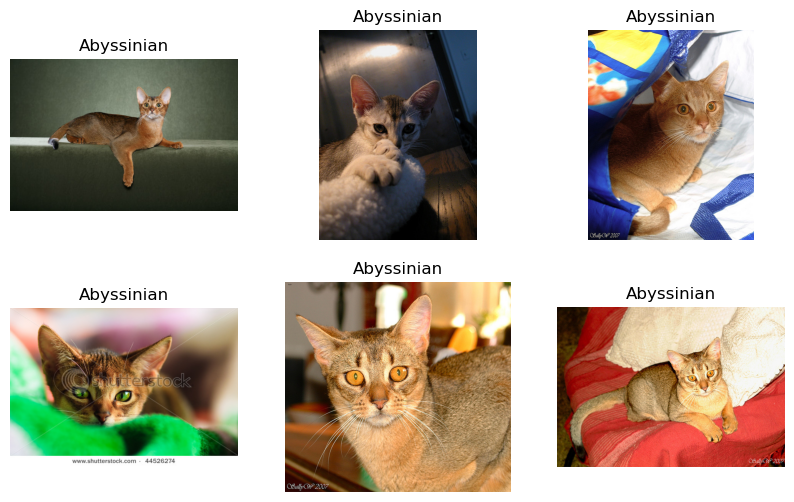

In [12]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = cv2.imread(df.iloc[i]['filepath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(df.iloc[i]['label'])
    plt.axis("off")

plt.show()

6.Train/Validation Split

In [13]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

7. Data Augmentation

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [15]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

8.Data Generators

In [16]:
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # VERY IMPORTANT
)

Found 5912 validated image filenames belonging to 35 classes.
Found 1478 validated image filenames belonging to 35 classes.


In [17]:
#train_generator = train_datagen.flow_from_dataframe(...)
#val_generator = val_datagen.flow_from_dataframe(...)

9.Build Model (Transfer Learning)

In [18]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

num_classes = len(train_generator.class_indices)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

10.Compile Model

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

11.Train Model

In [21]:
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    callbacks=[early_stop, lr_reduce] 
)

Epoch 1/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.2919 - loss: 2.8339 - val_accuracy: 0.7016 - val_loss: 1.6741 - learning_rate: 1.0000e-04
Epoch 2/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.6658 - loss: 1.3868 - val_accuracy: 0.8410 - val_loss: 0.7625 - learning_rate: 1.0000e-04
Epoch 3/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.7671 - loss: 0.8739 - val_accuracy: 0.8708 - val_loss: 0.5324 - learning_rate: 1.0000e-04
Epoch 4/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.8024 - loss: 0.6860 - val_accuracy: 0.8769 - val_loss: 0.4477 - learning_rate: 1.0000e-04
Epoch 5/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.8232 - loss: 0.5990 - val_accuracy: 0.8870 - val_loss: 0.4003 - learning_rate: 1.0000e-04
Epoch 6/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.8474 - loss: 0.5194 - val_accuracy: 0.8978 - val_loss: 0.3643 - learning_rate: 1.0000e-04
Epoch 7/8
185/185 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 

12.Accuracy & Loss Graphs

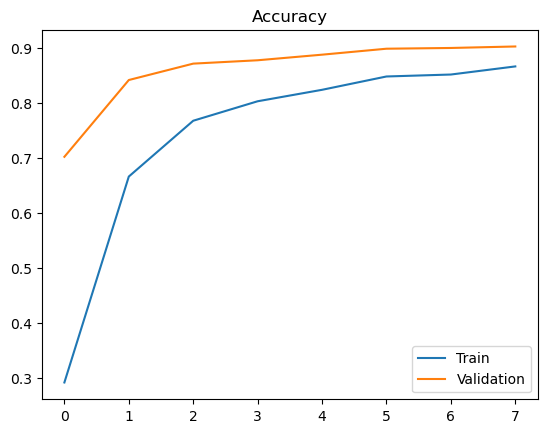

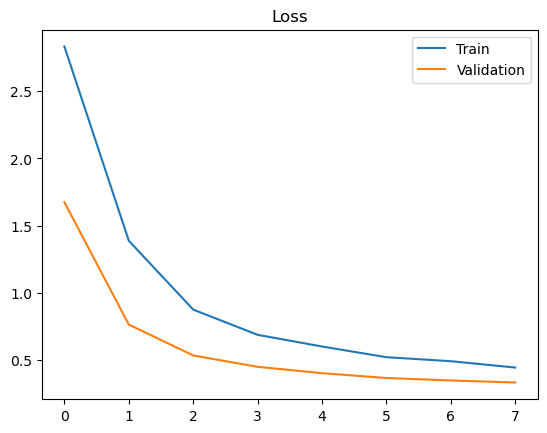

In [22]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

In [23]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


13 . Evaluation

In [24]:
val_generator.reset()

pred = model.predict(val_generator)
y_pred = np.argmax(pred, axis=1)

print(classification_report(val_generator.classes, y_pred))

47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 833ms/step
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        40
           1       0.97      0.75      0.85        40
           2       0.83      0.88      0.85        40
           3       0.95      0.93      0.94        40
           4       0.91      0.75      0.82        40
           5       0.84      0.90      0.87        40
           6       0.97      0.82      0.89        40
           7       0.89      1.00      0.94        40
           8       0.77      0.75      0.76        40
           9       0.74      0.85      0.79        40
          10       0.95      0.93      0.94        40
          11       0.93      0.97      0.95        40
          12       0.69      0.89      0.78        80
          13       0.93      0.95      0.94        40
          14       0.94      0.82      0.88        40
          15       0.93      0.93      0.93        40
          16       0.90      0.93      

14 . Confusion Matrix

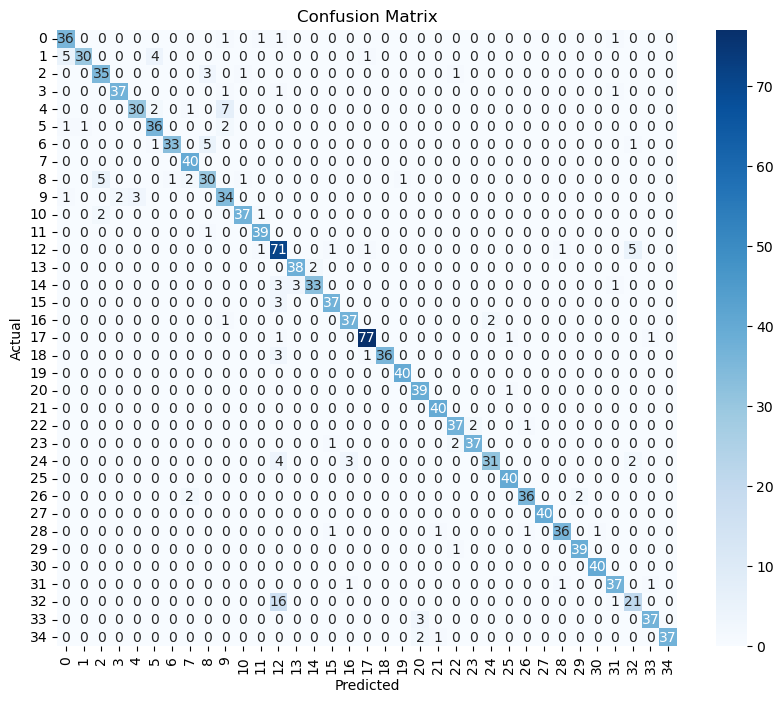

In [25]:
cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

15 . Save Model

In [39]:
model.save("object_detection_model.h5")

Conclusion :

The Pet Classification module successfully demonstrates the application of deep learning techniques for accurate image classification. By leveraging transfer learning with the MobileNetV2 architecture, the model achieves efficient feature extraction and high prediction performance on the Oxford-IIIT Pet dataset. The implementation includes data preprocessing, augmentation, model training, and comprehensive evaluation using accuracy metrics, loss curves, confusion matrix, and classification report.

Furthermore, the system supports both single and multiple image predictions, providing clear visual outputs along with confidence scores, which enhances its practical usability. The integration of performance visualization and optimized training strategies such as early stopping ensures model reliability and generalization.

Overall, this module highlights the effective use of modern convolutional neural networks for real-world image recognition tasks and can be extended to applications such as automated pet identification, veterinary assistance systems, and intelligent image tagging solutions.
